In [283]:
import torch
import sklearn

In [284]:
class MLPreg(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPreg, self).__init__()
        self.camada1 = torch.nn.Linear(input_dim, hidden_dim)
        self.lrelu = torch.nn.LeakyReLU()
        self.camada2 = torch.nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        z1 = self.camada1(x)
        a1 = self.lrelu(z1)
        z2 = self.camada2(a1)
        return z2

In [285]:
dataset = sklearn.datasets.fetch_california_housing()

x = dataset.data
y = dataset.target.reshape(-1, 1)
y[:5]

array([[4.526],
       [3.585],
       [3.521],
       [3.413],
       [3.422]])

In [286]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)




In [287]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_val = sc.transform(x_val)
x_test = sc.transform(x_test)


In [288]:
mlp = MLPreg(x_train.shape[1], 32, 1)
criterion = torch.nn.MSELoss()
optmizer = torch.optim.SGD(mlp.parameters(), lr=0.01)

losses = []

for epoch in range(1000):
    optmizer.zero_grad()
    y_pred = mlp(torch.tensor(x_train, dtype=torch.float32))
    loss = criterion(y_pred, torch.tensor(y_train, dtype=torch.float32))
    loss.backward()
    optmizer.step()
    if epoch % 10 == 0:
        y_pred_val = mlp(torch.tensor(x_val).float())
        loss_val = criterion(y_pred_val, torch.tensor(y_val).float())
        # print(f"Validation Loss: {loss_val.item():.4f}")
        losses.append((epoch, loss.item(), loss_val.item()))
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Validation Loss: {loss_val.item():.4f}")

Epoch 0, Loss: 5.8408, Validation Loss: 5.0668
Epoch 10, Loss: 2.3834, Validation Loss: 2.1099
Epoch 20, Loss: 1.4188, Validation Loss: 1.2765
Epoch 30, Loss: 1.0737, Validation Loss: 0.9879
Epoch 40, Loss: 0.9035, Validation Loss: 0.8537
Epoch 50, Loss: 0.8035, Validation Loss: 0.7794
Epoch 60, Loss: 0.7418, Validation Loss: 0.7360
Epoch 70, Loss: 0.7031, Validation Loss: 0.7100
Epoch 80, Loss: 0.6779, Validation Loss: 0.6937
Epoch 90, Loss: 0.6608, Validation Loss: 0.6827
Epoch 100, Loss: 0.6482, Validation Loss: 0.6744
Epoch 110, Loss: 0.6381, Validation Loss: 0.6674
Epoch 120, Loss: 0.6296, Validation Loss: 0.6612
Epoch 130, Loss: 0.6220, Validation Loss: 0.6554
Epoch 140, Loss: 0.6150, Validation Loss: 0.6498
Epoch 150, Loss: 0.6086, Validation Loss: 0.6444
Epoch 160, Loss: 0.6024, Validation Loss: 0.6393
Epoch 170, Loss: 0.5966, Validation Loss: 0.6343
Epoch 180, Loss: 0.5910, Validation Loss: 0.6294
Epoch 190, Loss: 0.5857, Validation Loss: 0.6246
Epoch 200, Loss: 0.5806, Valida

In [289]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [290]:
import matplotlib.pyplot as plt
# Plot Gráfico


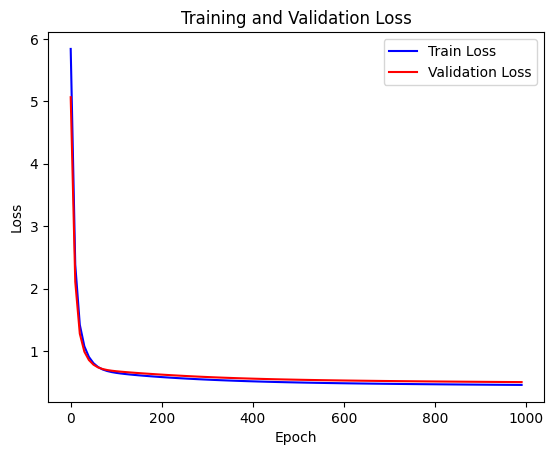

(0, 5.840821743011475, 5.066788673400879)

In [291]:
plt.plot([l[0] for l in losses], [l[1] for l in losses], label='Train Loss', color='blue')
plt.plot([l[0] for l in losses], [l[2] for l in losses], label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

losses[0]